In [105]:
import cv2
import torch
import numpy as np
from segment_anything import SamAutomaticMaskGenerator, SamPredictor, sam_model_registry

from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pdr
from marslab.bandset.mastcamz import ZcamBandSet, ls_zcam
from marslab.imgops.masking import skymask, threshold_mask

from roi_classifier import (
    add_rois,
    apply_homography,
    apply_kmeans_to_masked,
    average_spectra,
    compute_homography,
    filter_connected_components,
    load_data,
    LoadResult,
    mask_cube,
    plot_spectra,
    SHARED_BANDS,
    cluster_region,
    get_center_of_mass,
    get_roi
)
from pdr.pds4_tools.extern.zscale import zscale

from sklearn.cluster import KMeans
from roi_classifier import uncompress
from joblib import parallel_backend

from scipy.ndimage import binary_opening, binary_fill_holes, center_of_mass, find_objects, label, distance_transform_edt

In [ ]:
# pipeline settings

CLUSTER_KWARGS = {
    'edge_offset': 10,
    'allowed_variance': 5
}
ROI_AREA_THRESHOLD = 50
# DEGREE_OF_DIFF = 2.65  # number of standard deviations encompassed in a category
THRESHOLD_KWARGS = {
    'percentiles': (6, 99),
    'operator': 'and'
}
SKYMASK_KWARGS = {
    'percentile': 75,
    'edge_params': {"maximum": 5, "erosion": 3},
    'input_median': 5,
    'trace_maximum': 5,
    'cutoffs': {
        "extent": 0.05, "coverage": None, "v": 0.9, "h": None
    },
    'input_mask_dilation': None,
    'input_stretch': (10, 1),
    'floodfill': True,
    'trim_params': {"trim": False},
    'clear': True,
    'colorblock': False,
    'respect_mask': False,
}

### Load, Pre-process cube

In [107]:
# NOTE: get_zcam_bandset expects a directory structure like:
# sol
# sol/iof
# sol/pix_map

SEARCH_PATH = Path("data/new/1164/3")
SEQ_ID, OBS_IX = None, 0  # changed from 2
# NOTE: load_data crops the images inline; trim_margins() is no longer needed
load_result: LoadResult = load_data(
    SEARCH_PATH, seq_id=SEQ_ID, obs_ix=OBS_IX, do_apply_pixmaps=False  # changed to False
)

In [108]:
l_cube, r_cube = load_result["l_cube"], load_result["r_cube"]

In [109]:
# b/c we might have applied NaN values to bands of the cube, always use
# the original bands for computing homography (NaNs make cv2's SIFT
# implementation unhappy)

base_bands = load_result["base_bands"]
h_matrix = compute_homography(
    base_bands[SHARED_BANDS["L"]], base_bands[SHARED_BANDS["R"]],
)
l_cube_mapped = apply_homography(l_cube, h_matrix, r_cube[0].shape)

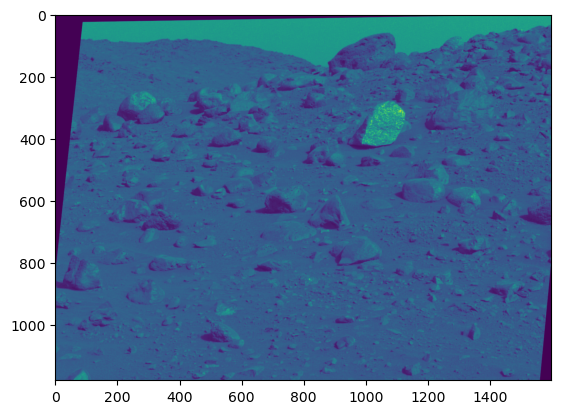

In [110]:
plt.imshow(l_cube_mapped[0])

In [114]:
shared_band_index = (
    sorted(load_result["bandset"].raw)
     .index(SHARED_BANDS['L'])
)
print(shared_band_index)

3


In [115]:
full_cube = []
shared_band_index = (
    sorted(load_result["bandset"].raw)
     .index(SHARED_BANDS['L'])
)
# average left/right views of Bayer and 800nm bands
for band in range(shared_band_index + 1):
    img = (l_cube_mapped[band] + r_cube[band]) / 2
    full_cube.append(img)

# add left bands
l_num_bands = l_cube.shape[0]
for band in range(shared_band_index + 1, l_num_bands):
    full_cube.append(l_cube[band])
    
# add right bands
r_num_bands = r_cube.shape[0]
for band in range(shared_band_index + 1, r_num_bands):
    full_cube.append(r_cube[band])

full_cube = np.array(full_cube)

In [116]:
full_cube.shape

(14, 1178, 1598)

### Masking shaddows and sky

In [117]:
# NOTE: this is an unnecessary copy if we didn't apply pixmaps
r_cube_base = np.array(
    [a for b, a in base_bands.items() if b.startswith('R')]
)
# mask shadows
shadow_tmask = threshold_mask(r_cube_base, **THRESHOLD_KWARGS)

# mask the sky
sky_tmask = skymask(r_cube_base, **SKYMASK_KWARGS)

del r_cube_base

In [118]:
# mask the overlap bewteen the cameras
overlap_mask = (l_cube_mapped[shared_band_index] == 0)

# combine the masks into one
feature_mask = np.logical_or(shadow_tmask, sky_tmask)
full_tmask = np.logical_or(feature_mask, overlap_mask)

#### NOTE 
I cut mask_bad_pixels() b/c I think it may be too
redundant and unstable with pixmap masking added to shadow
and sky masking. (the low end is redundant already!)

In [119]:
cube_preprocessed = mask_cube(full_cube, full_tmask)

cube_preprocessed.mask = (
    cube_preprocessed.mask | ~np.isfinite(cube_preprocessed)
)

### Identify small surfaces
# float_clustered = apply_kmeans_to_masked(cube_preprocessed, 
#                                          N_CLUSTERS["float"])
# float_rock_mask = filter_connected_components(float_clustered,
#                                               *FLOAT_MIN_MAX_AREA)

### Split scene into segments

In [124]:
from marslab.imgops.imgutils import enhance_color

In [125]:
enhance_color

<function marslab.imgops.imgutils.enhance_color(image: numpy.ndarray, bounds, stretch)>

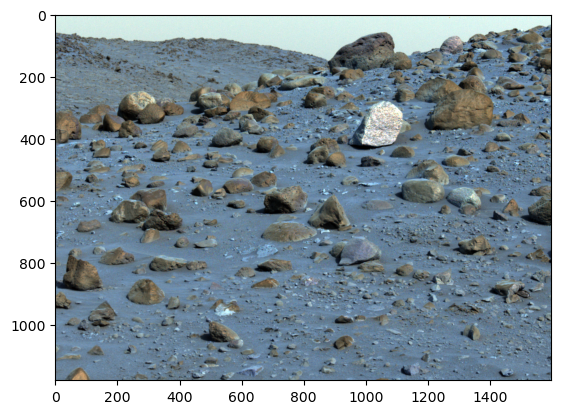

In [126]:
# creates rgb image from right bayer bands
red = r_cube[0]
green = r_cube[1]
blue = r_cube[2]

rgb = np.ma.masked_invalid(np.stack([red, green, blue], axis=-1))
rgb_normalized = enhance_color(rgb, (0, 1), 0.1)

plt.imshow(rgb_normalized)

In [127]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

sam = sam_model_registry[MODEL_TYPE](checkpoint="C:\\Users\\Lars\\Documents\\Python\\mars_lab\\models\\sam_vit_h_4b8939.pth")
sam.to(device=DEVICE)

predictor = SamPredictor(sam)
mask_generator = SamAutomaticMaskGenerator(sam)

output_mask = mask_generator.generate(rgb_normalized)

In [128]:
# sort segments based on pixel area
sorted_result = sorted(output_mask, key=(lambda x: x["area"]), reverse=True)

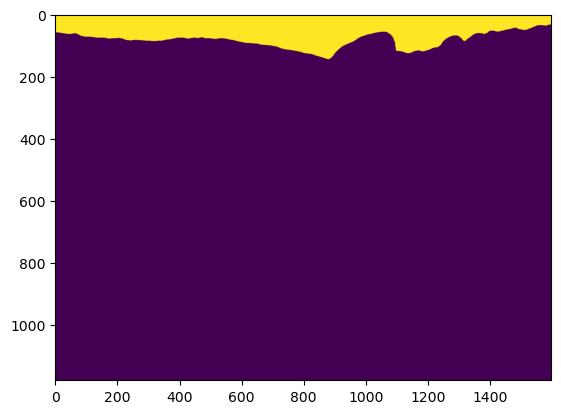

In [129]:
# visualize largest segment
plt.imshow(sorted_result[0]["segmentation"])

count=322


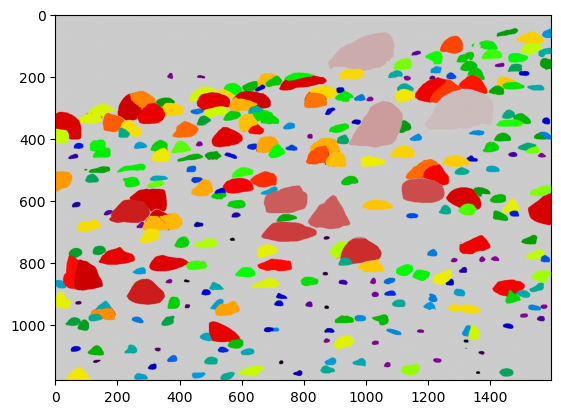

In [130]:
# create mask with unique label for each segment

dim = rgb_normalized.shape[:2]
classified_regions_mask = np.zeros(dim)

# populate mask
region_count = 0
for val in sorted_result:

    mask = val["segmentation"]
    classified_regions_mask[mask] = region_count

    region_count += 1

print(f"count={region_count}")

# fig, ax = plt.subplots(figsize=(12, 9))
ax = plt.gca()
fig = ax.get_figure()

ax.imshow(classified_regions_mask, cmap="nipy_spectral_r")

### Classify ROI in each segment

In [131]:
# compute average subtracted for clustering
r_bar = full_cube.mean(axis=(1, 2))
spectral_difference = np.transpose(full_cube, (1, 2, 0)) - r_bar
spectral_difference = np.transpose(spectral_difference, (2, 0, 1))
cube_spec_diff = mask_cube(spectral_difference, full_tmask)

In [334]:
rois = []

# loop physical SAM regions
for region_i in range(len(sorted_result)):

    # spectrally cluster
    region = [classified_regions_mask == region_i]
    cluster_ret = cluster_region(region, full_tmask, cube_spec_diff, **CLUSTER_KWARGS)

    if cluster_ret == None:
        continue

    # print(f'running with {region_i}')

    clusters, k = cluster_ret

    # identify roi for each cluster
    for cluster in range(k):

        slice = (clusters.data == cluster) & ~clusters.mask
        area, roi = get_roi(slice)

        rois.append(roi)

In [335]:
valid_rois = np.where([roi[2] * roi[3] >= ROI_AREA_THRESHOLD for roi in rois])[0]
area_constrained_rois = [rois[i] for i in valid_rois]

In [336]:
# filter rois based on spectral error and similarity

DO_APPLY_R_STAR = True

# NOTE: using Data.metaget() here can be sketchy
#  b/c ZCAM metadata has multiple solar elevation values
#  in different coordinate systems, not always in the same
#  order in different label versions!
if DO_APPLY_R_STAR is True:
    meta = load_result["bandset"].metadata
    incidence = meta["INCIDENCE_ANGLE"].unique().mean()
    photometric_scaling = np.cos(incidence * 2 * np.pi / 360)
else:
    photometric_scaling = 1

if DO_APPLY_R_STAR is False:
    y_axis_units = "IOF"
else:
    y_axis_units = "Relative Reflectance"

# scale the cube
photometrically_calibrated = cube_preprocessed / photometric_scaling

In [337]:
# convert rect coords to plot coords
plt_rois = []
for i in range(len(area_constrained_rois)):
    x1, y1, w, h = area_constrained_rois[i]
    x2 = x1 + w
    y2 = y1 + h
    plt_rois.append((x1, y1, x2, y2))

# calculate average spectra in roi regions
spectra, stds = average_spectra(photometrically_calibrated, plt_rois)

### Testing begins here... hold onto your butts

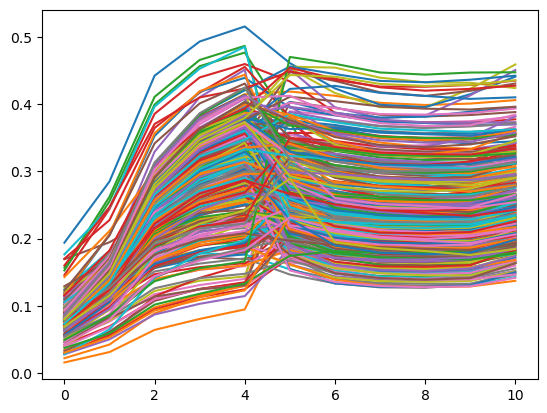

In [338]:
WLS = [630, 544, 480, 800, 754, 677, 605, 528, 442, 866, 910, 939, 978, 1022]

bayer_sorted_indices = np.argsort(WLS[:3])
non_bayer_sorted_indices = np.argsort(WLS[3:]) + 3

non_bayer_spectra = spectra[:, non_bayer_sorted_indices]

plt.plot(non_bayer_spectra.T)
plt.show()

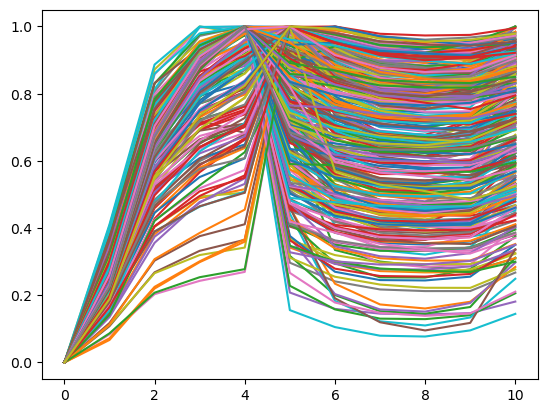

In [339]:
roi_spectra_norm = []

for s in non_bayer_spectra:
    spectra_norm = s.copy()
    
    min = spectra_norm.min()
    spectra_norm -= min

    max = spectra_norm.max()
    spectra_norm /= max
    
    roi_spectra_norm.append(spectra_norm)

roi_spectra_norm = np.array(roi_spectra_norm)

plt.plot(roi_spectra_norm.T)
plt.show()

In [ ]:
first_derivative = np.diff(roi_spectra_norm, axis=1)
second_derivative = np.diff(first_derivative, axis=1)

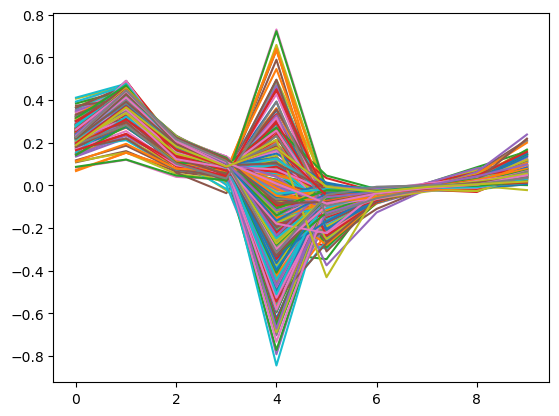

In [524]:
plt.plot(first_derivative.T)
plt.show()

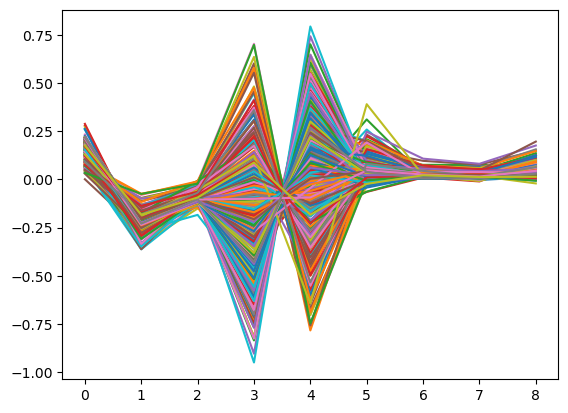

In [546]:
plt.plot(second_derivative.T)
plt.show()

In [557]:
keepers = [np.max(abs(s)) < 0.2 for s in second_derivative[:, 3:5]]
filtered_spectra = roi_spectra_norm[keepers]

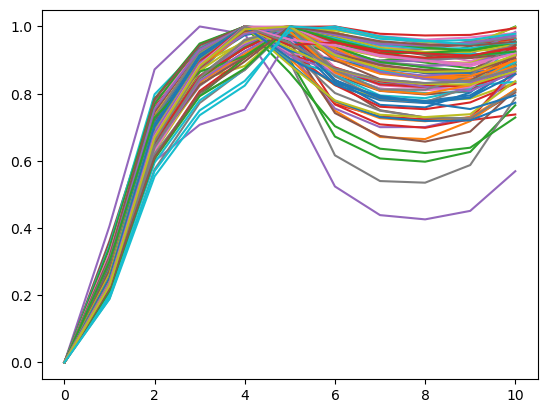

In [560]:
plt.plot(filtered_spectra.T)
plt.show()

In [573]:
k_means = KMeans(
    n_clusters=10, random_state=42
)  # NOTE: random state set to make deterministic
classifications = k_means.fit_predict(filtered_spectra)

c:\Users\Lars\anaconda3\envs\marslab\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


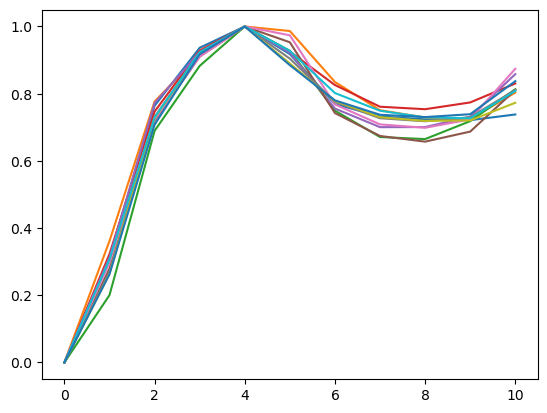

In [574]:
plt.plot(filtered_spectra[classifications == 0].T)
plt.show()

In [575]:
sorted, first_indices = np.unique(classifications, return_index=True)

In [576]:
first_indices

array([ 3,  1,  4, 24,  9,  8, 12,  0,  7,  6])

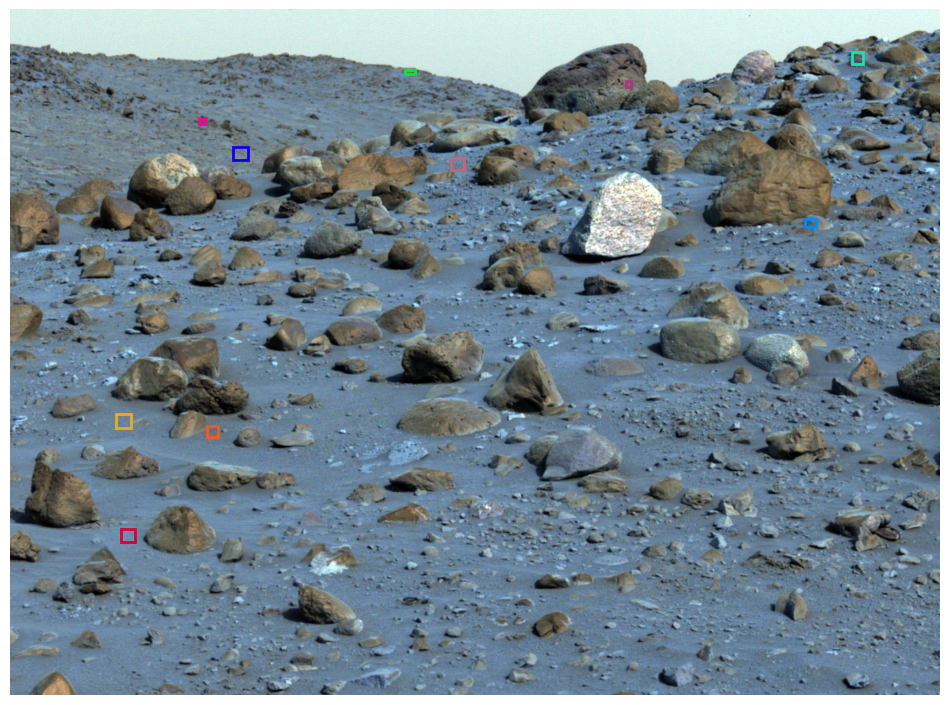

In [580]:
fig, ax = plt.subplots(figsize=(12, 9))
# fig, ax = plt.subplots()
fig.frameon = False
ax.set_axis_off()

im = ax.imshow(rgb_normalized)

COLORS = [
    "#ebac23",
    "#D80039",
    "#008cf9",
    "#AB358A",
    "#F5029F",
    "#0E00EE",
    "#00EB39",
    "#f05a28",
    "#15E4B1",
    "#D16174",
    "#136B8C",
    "#DD6E12",
    "#834C71",
]

color_i = 0
# for i, coord in enumerate(rois):
for i in first_indices:
    # unpack coords
    x1, y1, x2, y2 = area_constrained_rois[i]

    if color_i == len(COLORS):
        color_i = 0

    curr_color = COLORS[color_i]

    roi = patches.Rectangle(
        (x1, y1), x2, y2, edgecolor=curr_color, facecolor="none", linewidth=2
    )
    ax.add_patch(roi)

    color_i += 1

plt.show()

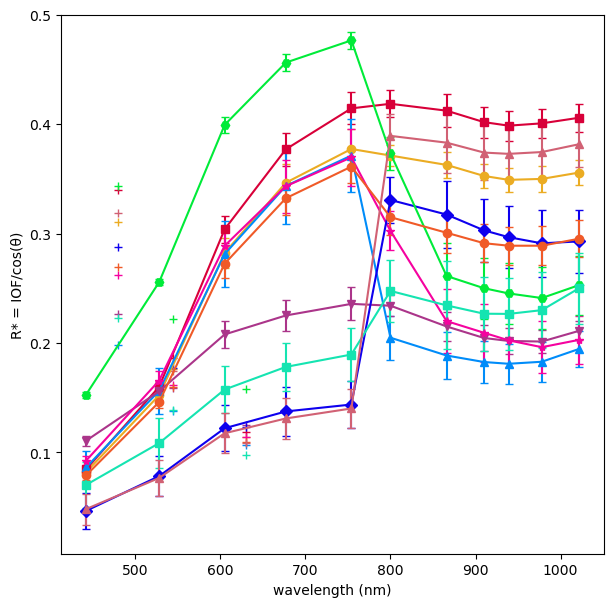

In [578]:
markers = ["o", "s", "^", "v", "*", "D", "H"]

plot_spectra(
    spectra[first_indices], stds[first_indices], COLORS, markers
)

### Testing ends here.

In [ ]:
DEGREE_OF_DIFF = 3.5  # number of standard deviations encompassed in a category

num_spectra = spectra.shape[0]
categorized = np.ones(num_spectra) * -1

# track categories
cats = []
cat_index = 0


for i in range(spectra.shape[0]):

    if categorized[i] != -1:
        continue

    s = spectra[i].copy()
    categorized[i] = cat_index
    similar = []
    similar.append(s)

    diffs = spectra - s
    diffs += abs(diffs.min(axis=0))
    diffs /= diffs.max(axis=0)

    diff_threshold = diffs.mean(axis=0) + diffs.std(axis=0) * DEGREE_OF_DIFF

    for j in range(spectra.shape[0]):

        if categorized[j] != -1:
            continue

        # diff = diffs[j]
        diff = spectra[j].copy() - s
        diff += abs(diff.min(axis=0))
        diff /= diff.max(axis=0)

        # if np.mean(diff) < DIFF_THRESHOLD:
        if np.all(diff < diff_threshold):
            # spectra are similar
            similar.append(spectra[j])
            categorized[j] = cat_index

    cats.append(similar)
    cat_index += 1

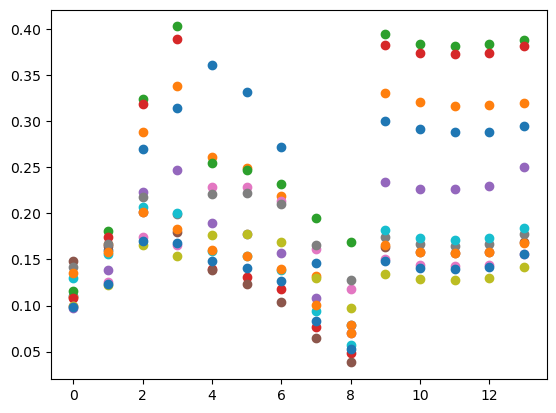

In [237]:
for cat in cats:
    plt.scatter(range(14), cat[0])

In [238]:
minimized_roi_indices = []

areas = [coords[2] * coords[3] for coords in area_constrained_rois]
max_area_diff = np.max(areas) - np.min(areas)

avg_errs = np.mean(stds, axis=1)
max_err_diff = np.max(avg_errs) - np.min(avg_errs)

# find roi with greatest area and least error
for category in np.unique(categorized):

    indices = np.where(categorized == category)[0]

    # max_area = 0
    curr_score = 0
    chosen_i = indices[0]

    for i in indices:
        coords = area_constrained_rois[i]
        curr_area = areas[i]
        avg_err = avg_errs[i]

        area_norm = (curr_area - np.min(areas)) / max_area_diff
        error_norm = (avg_err - np.min(avg_errs)) / max_err_diff
        score = area_norm - error_norm

        if score > curr_score:
            curr_score = score
            chosen_i = i

    minimized_roi_indices.append(chosen_i)

In [239]:
rgb_normalized.shape

(1178, 1598, 3)

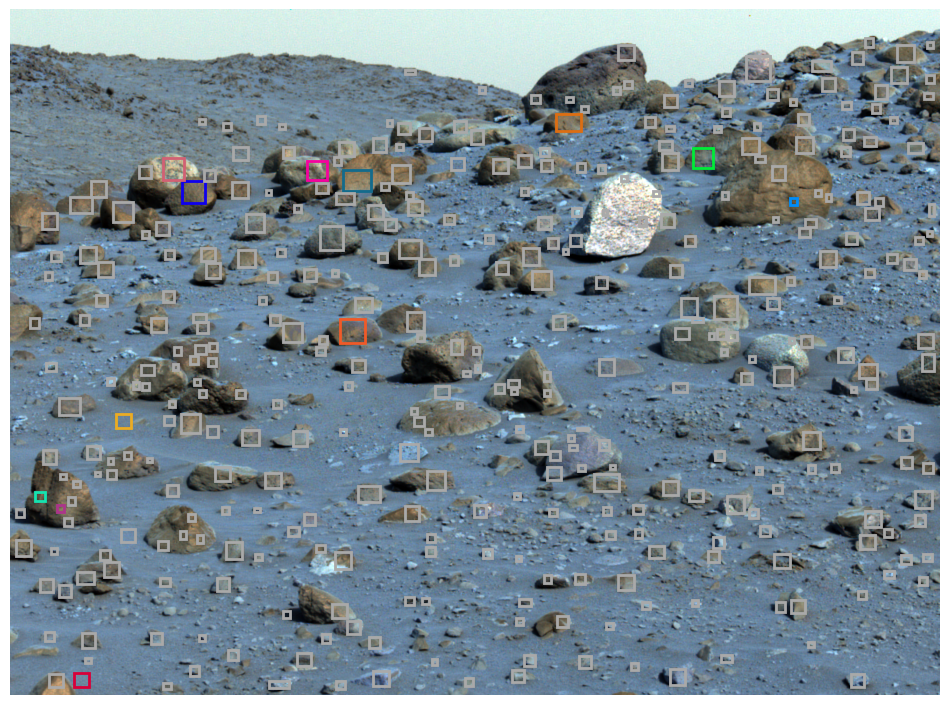

In [240]:
fig, ax = plt.subplots(figsize=(12, 9))
fig.frameon = False
ax.set_axis_off()

im = ax.imshow(rgb_normalized)

COLORS = [
    "#ebac23",
    "#D80039",
    "#008cf9",
    "#AB358A",
    "#F5029F",
    "#0E00EE",
    "#00EB39",
    "#f05a28",
    "#15E4B1",
    "#D16174",
    "#136B8C",
    "#DD6E12",
    "#834C71",
]

i = 0

color_i = 0
# for i, coord in enumerate(rois):
for coords in area_constrained_rois:
    # unpack coords
    x1, y1, x2, y2 = coords
    # print(coords)

    if i in minimized_roi_indices:
        if color_i == len(COLORS):
            color_i = 0

        curr_color = COLORS[color_i]
    else:
        curr_color = "darkgray"

    roi = patches.Rectangle(
        (x1, y1), x2, y2, edgecolor=curr_color, facecolor="none", linewidth=2
    )
    ax.add_patch(roi)

    if i in minimized_roi_indices:
        color_i += 1

    i += 1

plt.show()

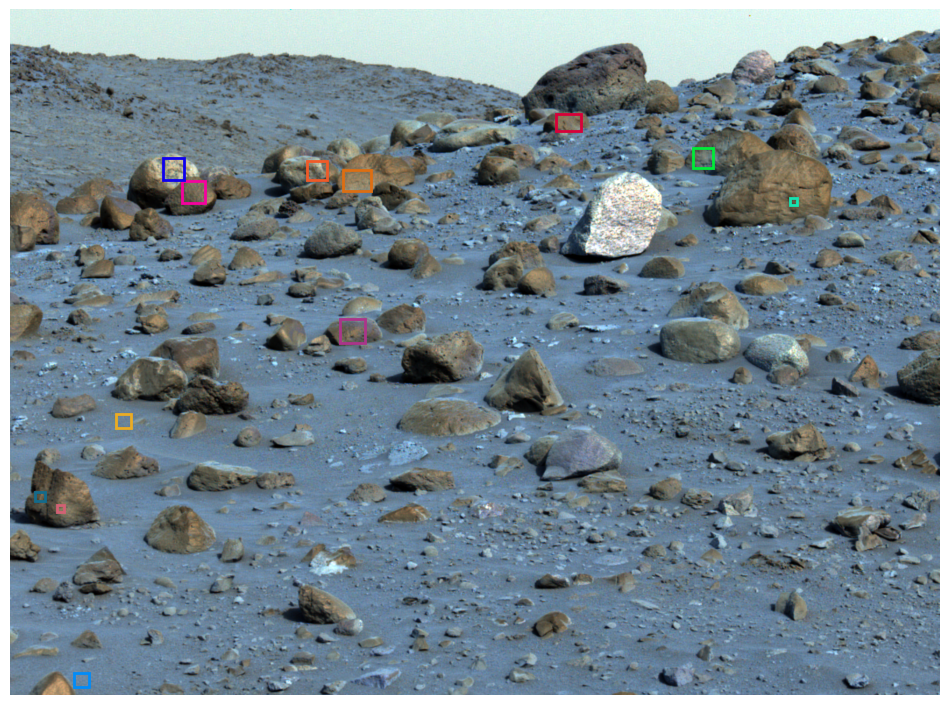

In [241]:
fig, ax = plt.subplots(figsize=(12, 9))
fig.frameon = False
ax.set_axis_off()

im = ax.imshow(rgb_normalized)

COLORS = [
    "#ebac23",
    "#D80039",
    "#008cf9",
    "#AB358A",
    "#F5029F",
    "#0E00EE",
    "#00EB39",
    "#f05a28",
    "#15E4B1",
    "#D16174",
    "#136B8C",
    "#DD6E12",
    "#834C71",
]

color_i = 0
# for i, coord in enumerate(rois):
for i in minimized_roi_indices:
    # unpack coords
    x1, y1, x2, y2 = area_constrained_rois[i]

    if color_i == len(COLORS):
        color_i = 0

    curr_color = COLORS[color_i]

    roi = patches.Rectangle(
        (x1, y1), x2, y2, edgecolor=curr_color, facecolor="none", linewidth=2
    )
    ax.add_patch(roi)

    color_i += 1

plt.show()

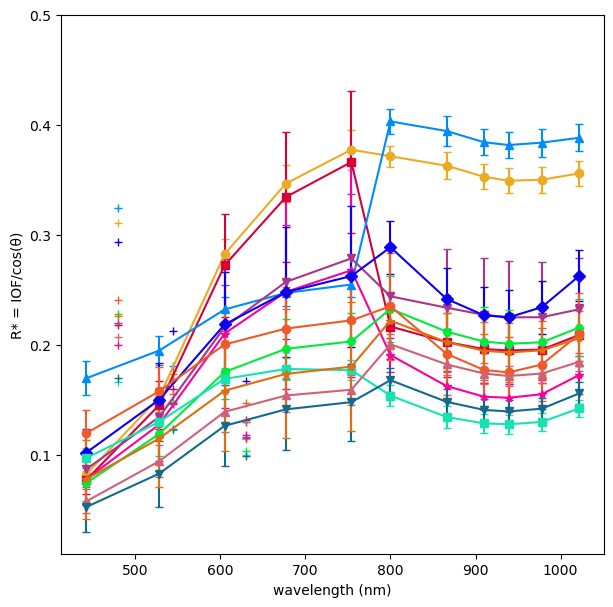

In [ ]:
markers = ["o", "s", "^", "v", "*", "D", "H"]

plot_spectra(
    spectra[minimized_roi_indices], stds[minimized_roi_indices], COLORS, markers
)

### Identify ROI in classifications

In [167]:
# s_rois = add_rois(s_clustered, **SMALL_ROI_PARAMS)
# l_rois = add_rois(l_clustered, **LARGE_ROI_PARAMS)

In [146]:
# # filter rois based on spectral error and similarity

# DO_APPLY_R_STAR = True

# # NOTE: using Data.metaget() here can be sketchy
# #  b/c ZCAM metadata has multiple solar elevation values
# #  in different coordinate systems, not always in the same
# #  order in different label versions!
# if DO_APPLY_R_STAR is True:
#     meta = load_result["bandset"].metadata
#     incidence = meta["INCIDENCE_ANGLE"].unique().mean()
#     photometric_scaling = np.cos(incidence * 2 * np.pi / 360)
# else:
#     photometric_scaling = 1

# if DO_APPLY_R_STAR is False:
#     y_axis_units = "IOF"
# else:
#     y_axis_units = "Relative Reflectance"

# # scale the cube
# photometrically_calibrated = cube_preprocessed / photometric_scaling

In [147]:
# rois = s_rois + l_rois

# # convert rect coords to plot coords
# plt_rois = []
# for i in range(len(rois)):
#     x1, y1, w, h = rois[i]
#     x2 = x1 + w
#     y2 = y1 + h
#     plt_rois.append((x1, y1, x2, y2))

# # calculate average spectra in roi regions
# spectra, stds = average_spectra(photometrically_calibrated, plt_rois)

In [148]:
# avg_err = stds.mean(axis=1)

In [149]:
# # testing using error as cutoff parameter
# # might delete...
# err_threshold = 0.05

# roi_to_omit = []
# for i, err in enumerate(avg_err):
#     if err > err_threshold:
#         roi_to_omit.append(i)

In [150]:
# # sanity check
# print(roi_to_omit)

In [151]:
# fig, ax = plt.subplots(figsize=(12, 9))
# im = ax.imshow(rgb_normalized)

# COLORS = [
#         "#ebac23",
#         "#D80039",
#         "#008cf9",
#         "#AB358A",
#         "#F5029F",
#         "#0E00EE",
#         "#00EB39",
#         "#f05a28",
#         "#15E4B1",
#         "#D16174",
#         "#136B8C",
#         "#DD6E12",
#         "#834C71"
#     ]

# color_i = 0
# for i, (x1, y1, x2, y2) in enumerate(rois):
#     if i in roi_to_omit:
#         continue
    
#     if color_i == len(COLORS):
#         color_i = 0
    
#     curr_color = COLORS[color_i]
    
#     roi = patches.Rectangle((x1, y1), x2, y2, edgecolor=curr_color, facecolor='none', linewidth=2)
#     ax.add_patch(roi)
    
#     color_i+=1

# plt.show()

In [152]:
# markers = [
#     'o',
#     's',
#     '^',
#     'v',
#     '*',
#     'D',
#     'H'
# ]

In [153]:
# plot_spectra(spectra, stds, COLORS, markers)

### testing...

In [154]:
# fits = pdr.read("C:\\Users\\Lars\\Downloads\\roi_SOL1376_zcam04056_RSM1458.fits.gz")

In [155]:
# fits

In [156]:
# fits['GREEN LEFT']

In [157]:
# plt.imshow(fits['GREEN LEFT'])